In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [4]:
#measurement parameters
laser_power_voltage = podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 2.93385e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = -5
pi_pulse = 52e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-H12-13'
sample = 'YBCO'
temperature = '80K'
b_field = '5mT_OOP_FC'
contact = 'OOC'
extra = ''

laser_waiting = 1.5e-6
tau_start = 0.1e-6
tau_stop = 5e-6
tau_num = 20
max_sweeps = 200000

tau_arr = np.linspace(tau_start, tau_stop, num=tau_num)

data = np.zeros_like(tau_arr)
data_alt = np.zeros_like(tau_arr)
data_delta = np.zeros_like(tau_arr)
data_err = np.zeros_like(tau_arr)
data_alt_err = np.zeros_like(tau_arr)
data_delta_err = np.zeros_like(tau_arr)

meas_dict = {}

meas_dict = {'params': {'Parameters for': 'MW waiting sweep'}}

meas_dict['params']['MW power (dBm)'] = power_0
meas_dict['params']['Pi pulse Duration (s)'] = pi_pulse
meas_dict['params']['Resonance frequency (Hz)'] = target_freq_0
meas_dict['params']['Measurement runs (#)'] = max_sweeps
meas_dict['params']['Tau (s)'] = tau_arr

meas_dict.update({'data': data})
meas_dict.update({'data_alt': data_alt})
meas_dict.update({'data_delta': data_delta})
meas_dict.update({'data_err': data_err})
meas_dict.update({'data_alt_err': data_alt_err})
meas_dict.update({'data_delta_err': data_delta_err})



for idx, tau in enumerate(tqdm(tau_arr)):

    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, pi_pulse_1=pi_pulse_1, mw_waiting_time=tau, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, switch_MW = switch_MW)
    pjl.Laser_waiting_sweep(laser_waiting, laser_waiting, 1)
    pjl.start_measurement(measurement_type='Laser-waiting-sweep', tip_name=tip_name, sample=sample, 
                          temperature=temperature, b_field=b_field, contact=contact, extra=extra)
    
    while True:
        if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
            pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
            data[idx], data_alt[idx], data_delta[idx] = pulsedmeasurementlogic_AWG.signal_data[1], pulsedmeasurementlogic_AWG.signal_data[2], pulsedmeasurementlogic_AWG.signal_data[1] - pulsedmeasurementlogic_AWG.signal_data[2]
            data_err[idx], data_alt_err[idx], data_delta_err[idx] = pulsedmasterlogic_AWG.measurement_error[1][0], pulsedmasterlogic_AWG.measurement_error[2][0],  pulsedmasterlogic_AWG.measurement_error[1][0] + pulsedmasterlogic_AWG.measurement_error[2][0]
            break
        else:
            time.sleep(0.001)

meas_dict['data'] = data
meas_dict['data_alt'] = data_alt
meas_dict['data_delta'] = data_delta

meas_dict['data_err'] = data_err
meas_dict['data_alt_err'] = data_alt_err
meas_dict['data_delta_err'] = data_delta_err

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'MW_waiting_sweep'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='MW waiting sweep')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

100%|#####################################################################################| 20/20 [01:33<00:00,  4.66s/it]


In [2]:
#measurement parameters
laser_power_voltage = podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 2.93385e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = -5
pi_pulse = 52e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-H12-13'
sample = 'YBCO'
temperature = '80K'
b_field = '5mT_OOP_FC'
contact = 'OOC'
extra = ''

laser_waiting = 1.5e-6
tau_start = 0.01e-6
tau_stop = 0.5e-6
tau_num = 20
max_sweeps = 500000

tau_arr = np.linspace(tau_start, tau_stop, num=tau_num)

data = np.zeros_like(tau_arr)
data_alt = np.zeros_like(tau_arr)
data_delta = np.zeros_like(tau_arr)
data_err = np.zeros_like(tau_arr)
data_alt_err = np.zeros_like(tau_arr)
data_delta_err = np.zeros_like(tau_arr)

meas_dict = {}

meas_dict = {'params': {'Parameters for': 'Read out  sweep'}}

meas_dict['params']['MW power (dBm)'] = power_0
meas_dict['params']['Pi pulse Duration (s)'] = pi_pulse
meas_dict['params']['Resonance frequency (Hz)'] = target_freq_0
meas_dict['params']['Measurement runs (#)'] = max_sweeps
meas_dict['params']['Tau (s)'] = tau_arr

meas_dict.update({'data': data})
meas_dict.update({'data_alt': data_alt})
meas_dict.update({'data_delta': data_delta})
meas_dict.update({'data_err': data_err})
meas_dict.update({'data_alt_err': data_alt_err})
meas_dict.update({'data_delta_err': data_delta_err})



for idx, tau in enumerate(tqdm(tau_arr)):

    pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, pi_pulse_1=pi_pulse_1, read_out_time=tau, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, switch_MW = switch_MW)
    pjl.Laser_waiting_sweep(laser_waiting, laser_waiting, 1)
    pjl.start_measurement(measurement_type='Laser-waiting-sweep', tip_name=tip_name, sample=sample, 
                          temperature=temperature, b_field=b_field, contact=contact, extra=extra)
    
    while True:
        if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
            pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
            data[idx], data_alt[idx], data_delta[idx] = pulsedmeasurementlogic_AWG.signal_data[1], pulsedmeasurementlogic_AWG.signal_data[2], pulsedmeasurementlogic_AWG.signal_data[1] - pulsedmeasurementlogic_AWG.signal_data[2]
            data_err[idx], data_alt_err[idx], data_delta_err[idx] = pulsedmasterlogic_AWG.measurement_error[1][0], pulsedmasterlogic_AWG.measurement_error[2][0],  pulsedmasterlogic_AWG.measurement_error[1][0] + pulsedmasterlogic_AWG.measurement_error[2][0]
            break
        else:
            time.sleep(0.001)

meas_dict['data'] = data
meas_dict['data_alt'] = data_alt
meas_dict['data_delta'] = data_delta

meas_dict['data_err'] = data_err
meas_dict['data_alt_err'] = data_alt_err
meas_dict['data_delta_err'] = data_delta_err

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'MW_waiting_sweep'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='MW waiting sweep')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

100%|#####################################################################################| 20/20 [01:33<00:00,  4.70s/it]


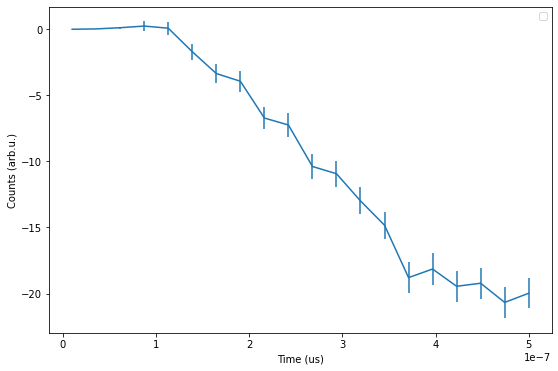

In [3]:
fig, ax1 = plt.subplots(1,1)


ax1.errorbar(x=tau_arr, y=data_delta,
                             yerr= data_delta_err)

ax1.set_xlabel('Time (us)')
ax1.set_ylabel('Counts (arb.u.)')
plt.legend()
plt.show()